# **Final Notebook: Baseline Global Feature Model**

In [1]:
#imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from src_final.features.global_feature_extractor import SurgicalFeatureExtractor
from src_final.models.analysis import leakage_free_correlation_analysis, leakage_free_residual_analysis
from src_final.models.baseline_loso import evaluate_loso_model

In [2]:
# file paths
processed_dir="data/processed/landmark_dataframes/" # NOTE the original results were obtained with "landmark_dataframes"
ratings_csv="data/scores/merged_scores.csv"

# create scores dataframe
df_ratings = pd.read_csv(ratings_csv)

# create all metrics dataframe
end = "_30fps_processed.pkl"
processed_files = sorted([f for f in os.listdir(processed_dir) if f.endswith(end)])
all_metrics = []

for filename in tqdm(processed_files):
    # Load raw tracking data
    df_raw = pd.read_pickle(os.path.join(processed_dir, filename))
    
    # Initialize and compute in one step
    extractor = SurgicalFeatureExtractor(df_raw, fps=30, min_disp=0, vel_threshold=30)
    
    # Get the 1-row dataframe of features
    feats = extractor.features_df
    feats["file"] = filename.replace('hand_tracking_', '').replace(end, '') # Add identifier
    
    all_metrics.append(feats)

# Combine all videos
df_all_metrics = pd.concat(all_metrics, ignore_index=True)

# Merge with scores (as you did before)
df_full = pd.merge(df_all_metrics, df_ratings, left_on="file", right_on="Vid_Name").drop(columns=["file"])

100%|██████████| 86/86 [00:21<00:00,  4.07it/s]


In [3]:
# remove a participant for reason to verify
df_full = df_full[df_full["Participant Number"] != 8]

## Feature Screening

- Correlation heatmap
- Intercorrelation heatmap

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

def plot_panel_a_feature_correlations(
    df_full,
    features,
    target="QRS_Overal",
    threshold=0.5,
    figsize=(8, 8),
    pos_color="#4C78A8AC",   # blue
    neg_color="#E456569B"    # red
):
    corrs = []

    # --- Compute correlations ---
    for feat in features:
        valid = df_full[[feat, target]].dropna()
        r, _ = spearmanr(valid[feat], valid[target])
        corrs.append(r)

    df_corr = pd.DataFrame({
        "feature": features,
        "spearman_corr": corrs
    })

    # --- Rank by absolute correlation ---
    df_corr["abs_corr"] = df_corr["spearman_corr"].abs()
    df_corr["sign"] = np.where(df_corr["spearman_corr"] >= 0, "Positive", "Negative")
    df_corr = df_corr.sort_values("abs_corr", ascending=False).reset_index(drop=True)

    # --- Colors by sign ---
    palette = {
        "Positive": pos_color,
        "Negative": neg_color
    }

    # --- Plot ---
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df_corr,
        x="spearman_corr",
        y="feature",
        hue="sign",
        dodge=False,
        palette=palette,
        orient="h"
    )

    # remove duplicate legend entries if seaborn creates them oddly
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Sign", loc="lower right")
    #ax.get_legend().remove()

    # --- Reference lines ---
    plt.axvline(0, color="black", linewidth=1.2)
    plt.axvline(threshold, linestyle="--", color="gray", linewidth=1.2)
    plt.axvline(-threshold, linestyle="--", color="gray", linewidth=1.2)

    # --- Highlight strong-correlation zone (top ranked features above threshold) ---
    strong_n = (df_corr["abs_corr"] >= threshold).sum()
    if strong_n > 0:
        ax.axhspan(-0.5, strong_n - 0.5, color="gray", alpha=0.12, zorder=0)
        ax.text(
            0.98, 0.98,
            f"Strong-correlation region\n(|r| ≥ {threshold:.1f}, n = {strong_n})",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray")
        )

    plt.xlabel("Spearman Correlation with GRS")
    plt.ylabel("Feature")
    plt.title("Ranked Correlation of Motion Descriptors with Surgical Skill")

    plt.tight_layout()
    plt.show()

    return df_corr

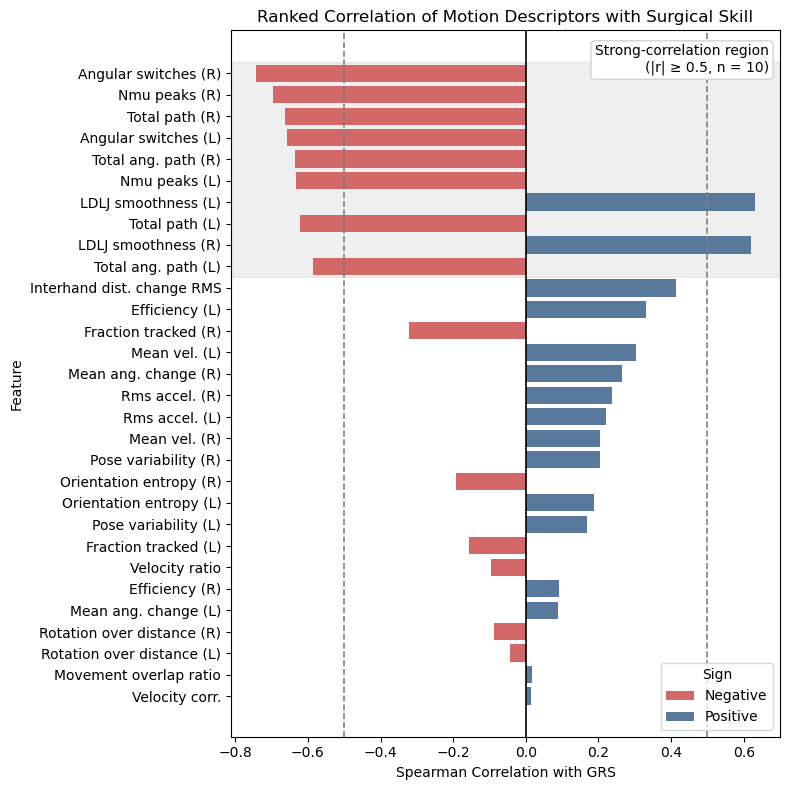

'Figure X shows the ranked correlations between all extracted motion descriptors and the GRS score. \nA small subset of descriptors exhibits strong correlations (|r| > 0.6), while the remaining features show substantially weaker associations (|r| < 0.4).'

In [5]:
all_features = [col for col in df_full if col not in df_ratings.columns]
df_corr = plot_panel_a_feature_correlations(df_full, all_features, target="QRS_Overal")


"""Figure X shows the ranked correlations between all extracted motion descriptors and the GRS score. 
A small subset of descriptors exhibits strong correlations (|r| > 0.6), while the remaining features show substantially weaker associations (|r| < 0.4)."""

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_panel_b_intercorrelation_heatmap(
    df_full,
    df_corr,
    target="QRS_Overal",
    plot_threshold=0.0,
    strong_threshold=0.5,
    figsize=(9,8)
):

    # select features above plot threshold
    df_corr = df_corr[df_corr["abs_corr"] >= plot_threshold]

    # features to include in the heatmap
    plot_features = df_corr["feature"].tolist()

    # strongly correlated subset
    strong_features = df_corr[df_corr["abs_corr"] >= strong_threshold]["feature"].tolist()
    n_top = len(strong_features)

    if n_top < 2:
        raise ValueError("Not enough features above threshold to compute intercorrelation.")

    # compute absolute correlation matrix
    corr_matrix = df_full[plot_features].corr(method="pearson").abs()

    plt.figure(figsize=figsize)

    ax = sns.heatmap(
        corr_matrix,
        annot=False,
        cmap="coolwarm",
        vmin=0,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Absolute Pearson Correlation", "shrink": 0.8}
    )

    # draw separation lines between top-signal features and the rest
    ax.axhline(n_top, color="black", linewidth=1.5)
    ax.axvline(n_top, color="black", linewidth=1.5)

    #plt.title("Intercorrelation of Motion Descriptors")

    # remove x labels to reduce clutter
    plt.xticks([])
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

    return corr_matrix

In [7]:
df_corr

,feature,spearman_corr,abs_corr,sign
0,Angular switches (R),-0.742872,0.742872,Negative
1,Nmu peaks (R),-0.695312,0.695312,Negative
2,Total path (R),-0.662657,0.662657,Negative
3,Angular switches (L),-0.657326,0.657326,Negative
4,Total ang. path (R),-0.636762,0.636762,Negative
5,Nmu peaks (L),-0.632251,0.632251,Negative
6,LDLJ smoothness (L),0.631167,0.631167,Positive
7,Total path (L),-0.621521,0.621521,Negative
8,LDLJ smoothness (R),0.620545,0.620545,Positive
9,Total ang. path (L),-0.584626,0.584626,Negative


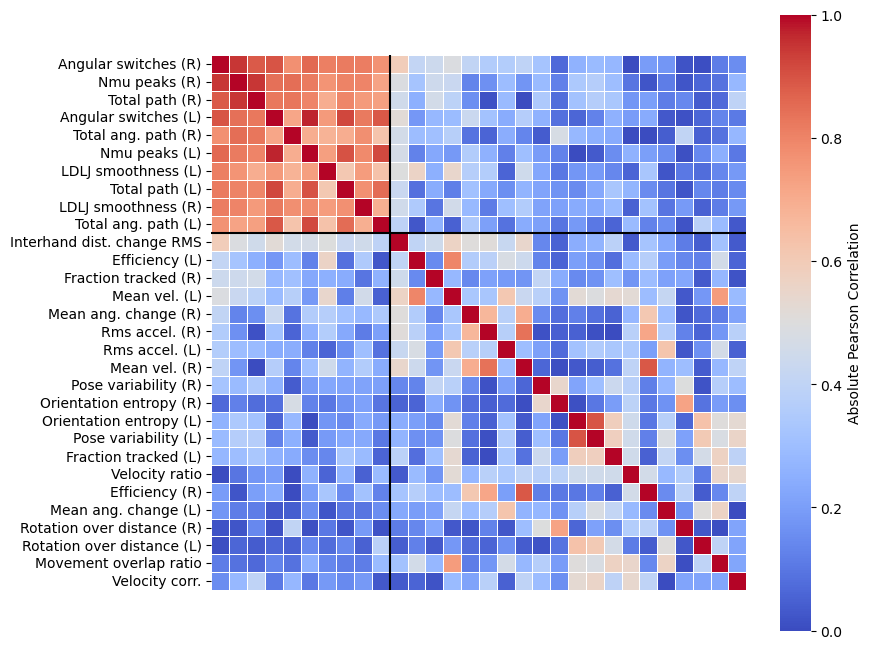

In [8]:
corr_matrix = plot_panel_b_intercorrelation_heatmap(
    df_full,
    df_corr,
    plot_threshold=0.0,
    strong_threshold=0.5
)

In [110]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import pearsonr

def plot_combined_feature_screening_figure(
    df_full,
    features,
    target="QRS_Overal",
    strong_threshold=0.5,
    figsize=(12, 9)
):

    # --- Compute correlations ---
    corrs = []
    for feat in features:
        valid = df_full[[feat, target]].dropna()
        r, _ = spearmanr(valid[feat], valid[target])
        corrs.append(r)

    df_corr = pd.DataFrame({
        "feature": features,
        "spearman_corr": corrs
    })

    df_corr["abs_corr"] = df_corr["spearman_corr"].abs()

    # sort by absolute correlation
    df_corr = df_corr.sort_values("abs_corr", ascending=False).reset_index(drop=True)
    ordered_features = df_corr["feature"].tolist()

    # compute intercorrelation matrix
    corr_matrix = df_full[ordered_features].corr().abs()

    n_features = len(df_corr)
    n_top = (df_corr["abs_corr"] >= strong_threshold).sum()

    # --- Create figure with constrained layout ---
    fig, (ax_bar, ax_heat) = plt.subplots(
        1, 2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [2, 4]},
        constrained_layout=True
    )

    y = np.arange(n_features) + 0.5

    # FIX 1: Generate a list of colors based on the sign of the original correlation
    # Using slightly muted blue and red for a polished look
    bar_colors = ["#4C78A8" if val >= 0 else "#E45756" for val in df_corr["spearman_corr"]]

    # ===== LEFT PANEL: correlation bars =====
    ax_bar.barh(y, df_corr["abs_corr"], color=bar_colors)

    ax_bar.set_yticks(y)
    ax_bar.set_yticklabels(df_corr["feature"])
    ax_bar.set_ylim(n_features, 0)
    ax_bar.grid(axis="x", linestyle="--", alpha=0.7)

    ax_bar.set_xlabel(r"$|r|$ with GRS")
    #ax_bar.axvline(strong_threshold, linestyle="--", color="gray")

    # separation line
    if n_top > 0:
        # FIX 2: clip_on=False and xmax=1.5 forces the line to shoot into the gap between subplots
        ax_bar.axhline(n_top, color="black", linewidth=1.5, xmin=-0.65, xmax=1.5, clip_on=False, zorder=10)

    # Add a custom legend to explain the colors
    legend_elements = [
        Patch(facecolor='#4C78A8', label='Positive Corr (> 0)'),
        Patch(facecolor='#E45756', label='Negative Corr (< 0)')
    ]
    ax_bar.legend(handles=legend_elements, loc='lower right', fontsize=10)

    # cleaner look
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)

    # ===== RIGHT PANEL: heatmap =====
    sns.heatmap(
        corr_matrix,
        ax=ax_heat,
        cmap="coolwarm",
        vmin=0,
        vmax=1,
        linewidths=0.4,
        linecolor="white",
        #cbar_kws={"label": "Absolute Pearson Correlation"}
    )

    ax_heat.collections[0].colorbar.set_label("Absolute Pearson Correlation", fontsize=12)

    ax_heat.set_xticks([])
    ax_heat.set_yticks(y) 
    ax_heat.set_yticklabels([])

    # separation lines
    if n_top > 0:
        # FIX 2 (cont): xmin=-0.1 catches the line coming from the left plot, sealing the gap perfectly
        ax_heat.axhline(n_top, color="black", linewidth=1.5, xmin=-0.1, clip_on=False, zorder=10)
        ax_heat.axvline(n_top, color="black", linewidth=1.5)

    #ax_heat.set_title("Intercorrelation of Motion Descriptors")

    # save 
    plt.savefig(
        "feature_screening_combined.pdf",
        bbox_inches="tight",
        dpi=300
    )

    plt.show()

    return df_corr, corr_matrix

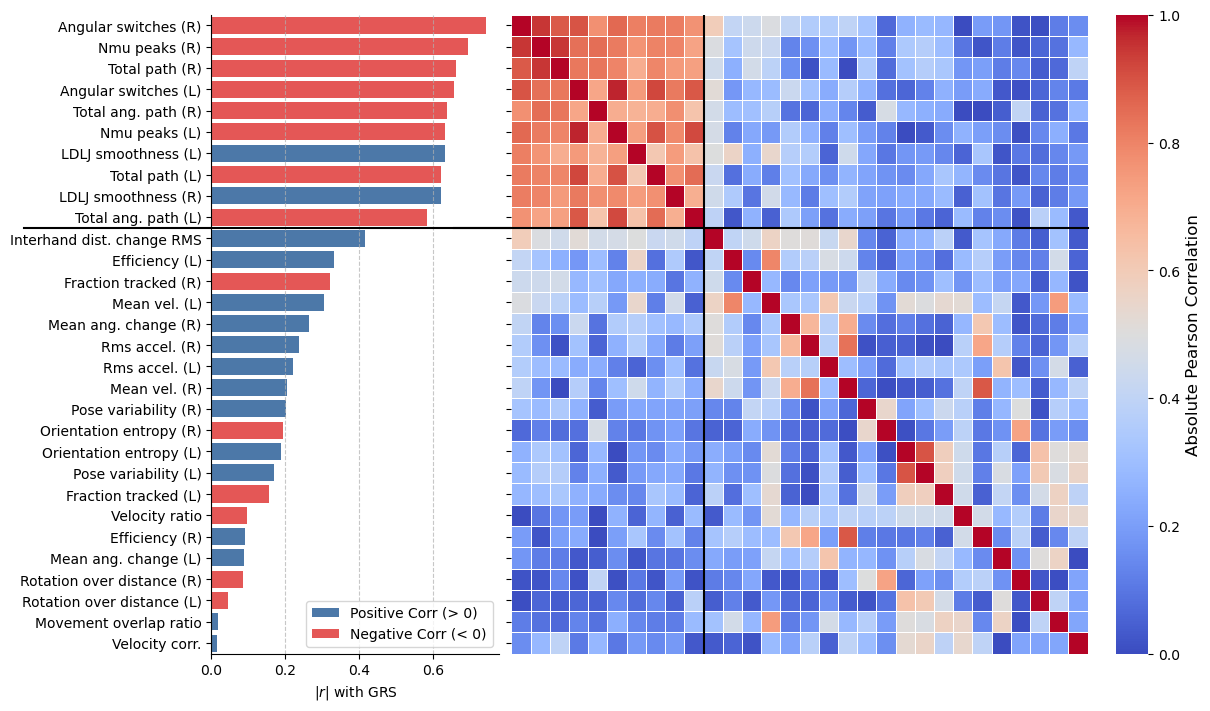

In [111]:
df_corr, corr_matrix =plot_combined_feature_screening_figure(
    df_full,
    all_features,
    target="QRS_Overal",
    strong_threshold=0.5,
    figsize=(12, 7)
)

In [127]:
df = corr_matrix.loc[df_corr[df_corr["abs_corr"] >= 0.5]['feature'].tolist(), df_corr[df_corr["abs_corr"] >= 0.5]['feature'].tolist()]

print("mean correlation among top features:", df.stack().mean(axis=None), "±", df.stack().std(axis=None))

mean correlation among top features: 0.8146622490780138 ± 0.10275044091338591


In [124]:
df.mean(axis=None)

np.float64(0.8146622490780138)

## Use top Features Only

Extract features that are highly correlated with scores (>0.5) over all folds

In [10]:
# correlation between features and scores
all_features = [col for col in df_full if col not in df_ratings.columns]
right_features = [col for col in all_features if 'Left' not in col]
left_features = [col for col in all_features if 'Right' not in col]

fair_corr_df = leakage_free_correlation_analysis(df_full, all_features, n=6)
fair_corr_df

Analyzing Folds: 100%|██████████| 28/28 [00:00<00:00, 55.00it/s]


,Feature,Mean_Corr_with_Target,Std_Corr_with_Target,Min_Corr_with_Target,Max_Corr_with_Target,Selection_Stability
1,Angular switches (R),-0.714735,0.011032,-0.750897,-0.697865,1.000000
15,Nmu peaks (R),-0.693120,0.012649,-0.730681,-0.675887,1.000000
27,Total path (R),-0.669737,0.014455,-0.708289,-0.651589,1.000000
0,Angular switches (L),-0.663125,0.012844,-0.689274,-0.641461,1.000000
14,Nmu peaks (L),-0.642331,0.013161,-0.663441,-0.618091,1.000000
7,LDLJ smoothness (L),0.638477,0.015777,0.610076,0.688787,0.892857
25,Total ang. path (R),-0.617772,0.012847,-0.646571,-0.601983,0.035714
8,LDLJ smoothness (R),0.616430,0.011857,0.591682,0.639987,0.000000
26,Total path (L),-0.613678,0.015388,-0.645383,-0.574732,0.035714
24,Total ang. path (L),-0.585841,0.016884,-0.629634,-0.541356,0.035714


In [11]:
top_features = fair_corr_df[(abs(fair_corr_df['Min_Corr_with_Target']) > 0.5) & (abs(fair_corr_df['Max_Corr_with_Target']) > 0.5)]['Feature'].tolist()

# top feature intercorrelation
inter_corrs = df_full[top_features].corr()


top_features_right = [feat for feat in top_features if '(R)' in feat]
top_features_left = [feat for feat in top_features if '(L)' in feat]

In [12]:
top_features_right

['Angular switches (R)',
 'Nmu peaks (R)',
 'Total path (R)',
 'Total ang. path (R)',
 'LDLJ smoothness (R)']

# Try Some Models with these Features
- using all features
- using only the top correlated features

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 28.55it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.6996 | MAE: 5.4253 | MAE STD: 4.2263 | R2: 0.4541 | Adj R2: 0.4110

Feature Weights:
                Feature  Average_Weight  Std_Weight
0                  bias       49.938586    0.302804
1  Angular switches (R)       -4.723377    0.339790
2         Nmu peaks (R)        0.000000    0.000000
3        Total path (R)       -0.765687    0.408578
4   Total ang. path (R)       -0.997296    0.272721
5   LDLJ smoothness (R)        0.352695    0.216365

--- Per-Fold Performance Summary ---


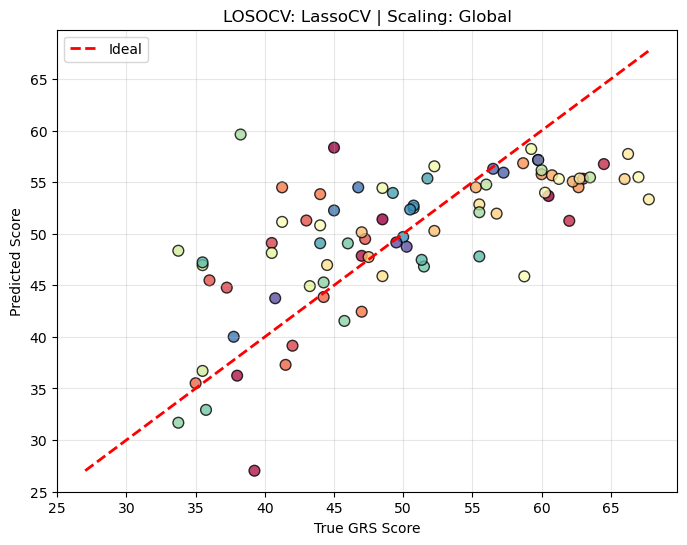

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 100.57it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7246 | MAE: 5.3787 | MAE STD: 4.1691 | R2: 0.4655 | Adj R2: 0.4521

Feature Weights:
                Feature  Average_Weight  Std_Weight
0                  bias       49.938586    0.302804
1  Angular switches (R)       -6.567227    0.155501

--- Per-Fold Performance Summary ---


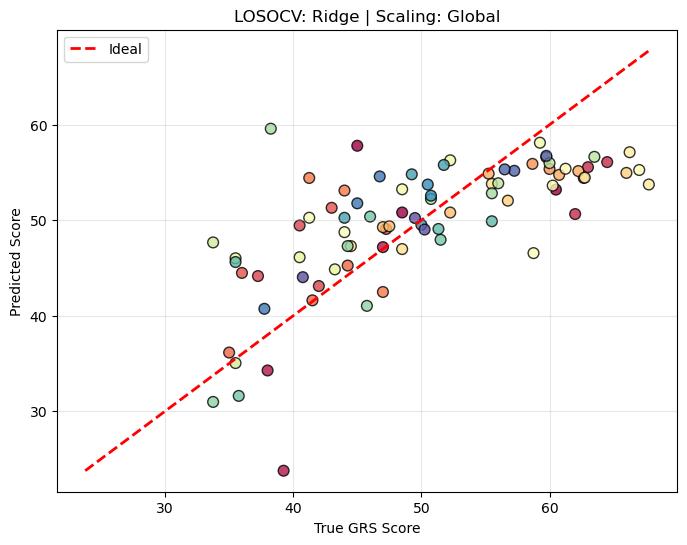

In [147]:
# Ridge
from sklearn.linear_model import Ridge, LassoCV, ElasticNetCV, LinearRegression, RidgeCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
_, _, _ = evaluate_loso_model(df_full, top_features_right, model_class=LassoCV, model_params={'alphas': np.logspace(-1, 2, 30)})
_, _, _ = evaluate_loso_model(df_full, ['Angular switches (R)'], model_class=Ridge, model_params={})

# All Top Features are Highly Inter-Correlated
- Combine all of them with PCA, in one component PC1
- Combine only right features in PC1
- Combine both right and left features in separate right_PC1 + left_PC1

In [136]:
inter_corrs

,Angular switches (R),Nmu peaks (R),Total path (R),Angular switches (L),Nmu peaks (L),LDLJ smoothness (L),Total ang. path (R),LDLJ smoothness (R),Total path (L),Total ang. path (L)
Angular switches (R),1.000000,0.947856,0.886434,0.896690,0.855630,-0.811619,0.773407,-0.815964,0.816461,0.769001
Nmu peaks (R),0.947856,1.000000,0.946420,0.840396,0.818757,-0.763363,0.847031,-0.800735,0.803458,0.725525
Total path (R),0.886434,0.946420,1.000000,0.825805,0.797656,-0.698809,0.829852,-0.747065,0.793139,0.730590
Angular switches (L),0.896690,0.840396,0.825805,1.000000,0.972519,-0.747190,0.717532,-0.821330,0.920183,0.889560
Nmu peaks (L),0.855630,0.818757,0.797656,0.972519,1.000000,-0.737335,0.696736,-0.787495,0.900756,0.917574
LDLJ smoothness (L),-0.811619,-0.763363,-0.698809,-0.747190,-0.737335,1.000000,-0.681582,0.745644,-0.611928,-0.630447
Total ang. path (R),0.773407,0.847031,0.829852,0.717532,0.696736,-0.681582,1.000000,-0.774123,0.697958,0.627222
LDLJ smoothness (R),-0.815964,-0.800735,-0.747065,-0.821330,-0.787495,0.745644,-0.774123,1.000000,-0.772425,-0.694242
Total path (L),0.816461,0.803458,0.793139,0.920183,0.900756,-0.611928,0.697958,-0.772425,1.000000,0.847669
Total ang. path (L),0.769001,0.725525,0.730590,0.889560,0.917574,-0.630447,0.627222,-0.694242,0.847669,1.000000


In [137]:
# with all top features
scaler = StandardScaler()
X = scaler.fit_transform(df_full[top_features].values)

pca = PCA(n_components=len(top_features))
pca.fit(X)
components = pca.components_
explained_variance = pca.explained_variance_ratio_

df = pd.DataFrame(components, columns=top_features)
df['Explained_Variance'] = explained_variance
print('PC1 explained variance:', explained_variance[0])

PC1 explained variance: 0.8166427678945312


In [142]:
# right features only
scaler = StandardScaler()
X = scaler.fit_transform(df_full[top_features_right].values)

pca_r = PCA(n_components=len(top_features_right))
pca_r.fit(X)
components = pca_r.components_
explained_variance = pca_r.explained_variance_ratio_

df = pd.DataFrame(components, columns=top_features_right)
df['Explained_Variance'] = explained_variance
print('PC1 explained variance (right features):', explained_variance[0])
pc1_right = pca_r.transform(X)[:, 0]

# left features only
scaler = StandardScaler()
X = scaler.fit_transform(df_full[top_features_left].values)

pca_l = PCA(n_components=len(top_features_left))
pca_l.fit(X)
components = pca_l.components_
explained_variance = pca_l.explained_variance_ratio_
df = pd.DataFrame(components, columns=top_features_left)
df['Explained_Variance'] = explained_variance
print('PC1 explained variance (left features):', explained_variance[0])
pc1_left = pca.transform(X)[:, 0]

# corrlation between right and left PC1
correlation = pd.Series(pc1_right).corr(pd.Series(pc1_left))
print('Correlation between right and left PC1:', correlation)

df_full['pc1_left'] = pc1_left

PC1 explained variance (right features): 0.870552513801391
PC1 explained variance (left features): 0.8583751618039869
Correlation between right and left PC1: 0.8879768885485259


In [145]:
print(top_features_right)
print(pca_r.components_[0])

['Angular switches (R)', 'Nmu peaks (R)', 'Total path (R)', 'Total ang. path (R)', 'LDLJ smoothness (R)']
[ 0.45544729  0.46770251  0.45417242  0.43349292 -0.42383185]


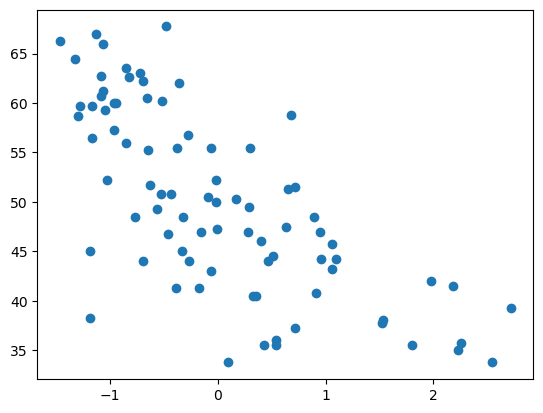

In [139]:
# plot relationship pc1 vs scores
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
scaler = StandardScaler()
plt.scatter(scaler.fit_transform(pc1_right.reshape(-1, 1)), df_full['QRS_Overal'])

## Model With PCA features

LOSOCV Folds:   0%|          | 0/28 [00:00<?, ?it/s]

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 63.67it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.6994 | MAE: 5.4669 | MAE STD: 3.9248 | R2: 0.4773 | Adj R2: 0.4642

Feature Weights:
  Feature  Average_Weight  Std_Weight
0    bias       49.938586    0.302804
1     PC1       -6.517159    0.158956

--- Per-Fold Performance Summary ---


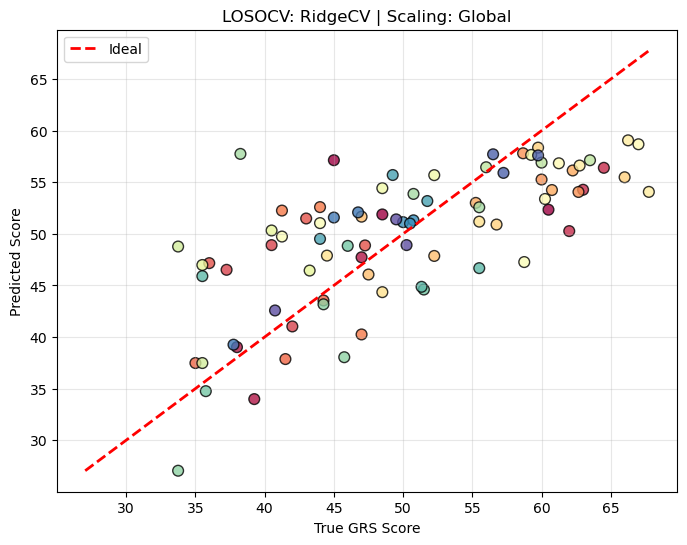

In [151]:
_, _, _ = evaluate_loso_model(df_full, top_features, model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 1, 20)}, pca_components=[0])

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 68.11it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.6925 | MAE: 5.3523 | MAE STD: 4.1144 | R2: 0.4740 | Adj R2: 0.4608

Feature Weights:
  Feature  Average_Weight  Std_Weight
0    bias       49.938586    0.302804
1     PC1       -6.480732    0.160467

--- Per-Fold Performance Summary ---


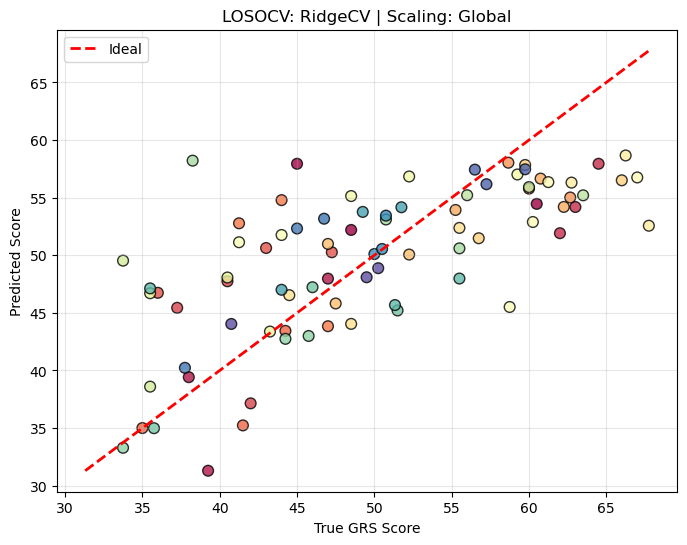

In [155]:
_, _, _ = evaluate_loso_model(df_full, top_features_right, model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 1, 20)}, pca_components=[0])

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 56.84it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.6617 | MAE: 5.7780 | MAE STD: 4.0821 | R2: 0.4223 | Adj R2: 0.4079

Feature Weights:
  Feature  Average_Weight  Std_Weight
0    bias       49.938586    0.302804
1     PC1       -6.153575    0.172987

--- Per-Fold Performance Summary ---


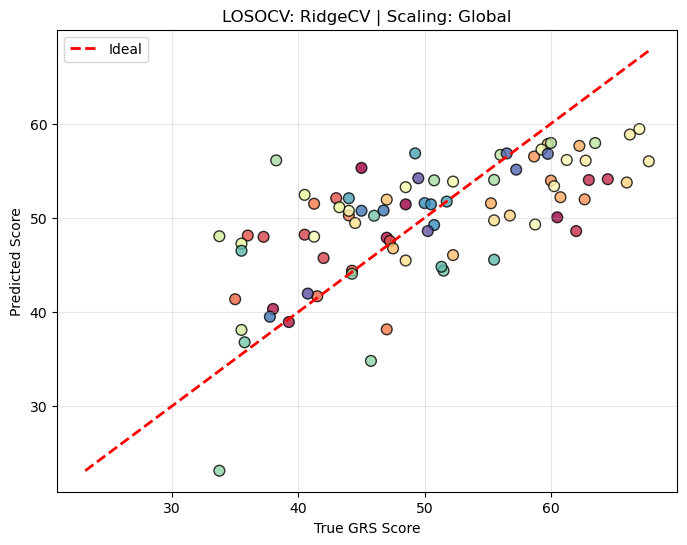

In [19]:
_, _, _ = evaluate_loso_model(df_full, top_features_left, model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 1, 20)}, pca_components=[0])

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 51.65it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.6947 | MAE: 5.4291 | MAE STD: 3.9706 | R2: 0.4778 | Adj R2: 0.4580

Feature Weights:
    Feature  Average_Weight  Std_Weight
0      bias       49.938586    0.302804
1       PC1       -3.907335    0.268482
2  pc1_left       -2.635009    0.216293

--- Per-Fold Performance Summary ---


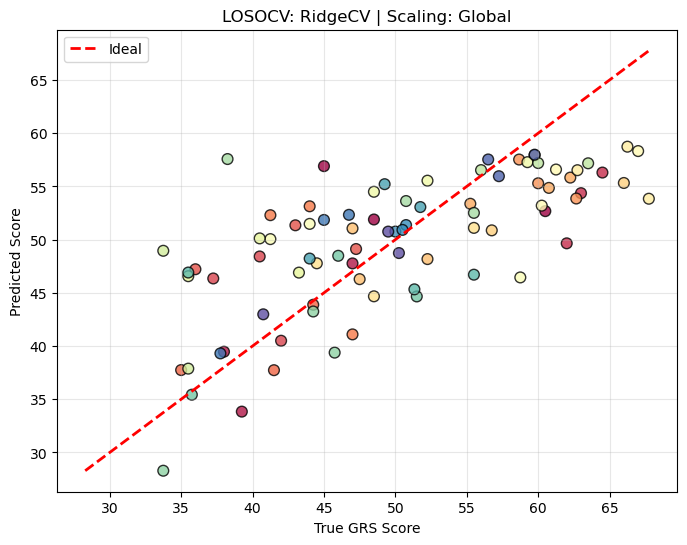

In [20]:
_, _, _ = evaluate_loso_model(df_full, top_features_right, extra_features=['pc1_left'], model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 1, 20)}, pca_components=[0])

## How Well Do the Remaining Features Explain the Residuals of PC1 only Ridge Model?

In [22]:
# right features only in pc1
candidate_features = [feat for feat in all_features if feat not in top_features_right]

df_res_leakage_free = leakage_free_residual_analysis(df_full, top_features_right, candidate_features=candidate_features, top_n=1, test_other_pcs=True)
df_res_leakage_free

,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
27,Velocity corr.,0.105581,0.015863,0.051399,-0.305214,0.964286
28,Velocity ratio,0.039488,0.010917,0.015732,-0.194581,0.000000
6,LDLJ smoothness (L),0.031395,0.011589,0.012375,0.121594,0.035714
8,Mean ang. change (R),0.026621,0.006424,0.014429,0.161103,0.000000
21,Rms accel. (L),0.026414,0.007254,0.004627,-0.144506,0.000000
19,Pose variability (L),0.018453,0.006472,0.004615,-0.118622,0.000000
3,Fraction tracked (L),0.017340,0.005769,0.006474,0.115773,0.000000
23,Rotation over distance (L),0.016726,0.008040,0.005243,-0.123967,0.000000
18,PCA_Comp_5,0.014948,0.005129,0.004415,0.118809,0.000000
14,Orientation entropy (R),0.014558,0.004904,0.003863,-0.118610,0.000000


In [14]:
# right pc1 and left pc1
candidate_features = [feat for feat in all_features if feat not in top_features]

df_res_leakage_free = leakage_free_residual_analysis(df_full, top_features_right, base_features=['pc1_left'], candidate_features=candidate_features, top_n=1, test_other_pcs=True)
df_res_leakage_free

KeyError: ['pc1_left']

### Hybrid Model PC1 + Velocity Corr

Significant imporvement!

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 63.41it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7227 | MAE: 5.2740 | MAE STD: 3.8273 | R2: 0.5099 | Adj R2: 0.4913

Feature Weights:
         Feature  Average_Weight  Std_Weight
0           bias       49.938586    0.302804
1            PC1       -7.147245    0.170219
2  velocity_corr       -2.122305    0.184371

--- Per-Fold Performance Summary ---


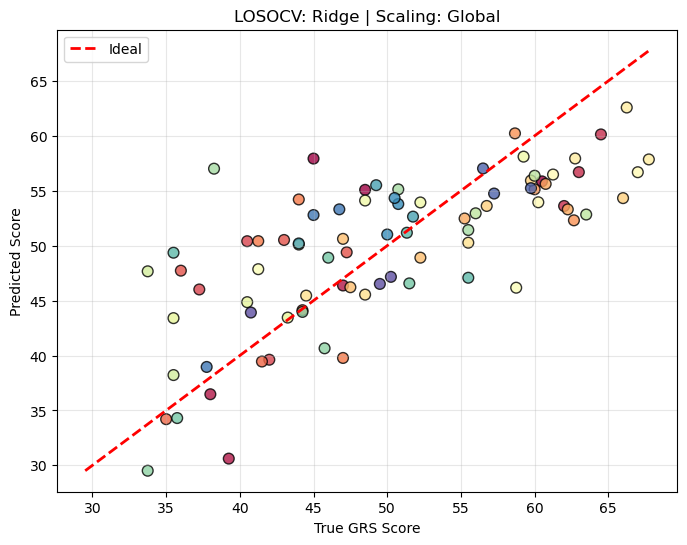

In [19]:
_, _, _ = evaluate_loso_model(df_full, top_features_right, extra_features=['velocity_corr'], model_class=Ridge, pca_components=[0], print_fold_metrics=False)

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 54.77it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7183 | MAE: 5.3793 | MAE STD: 3.8390 | R2: 0.4959 | Adj R2: 0.4700

Feature Weights:
         Feature  Average_Weight  Std_Weight
0           bias       49.938586    0.302804
1            PC1       -6.340390    0.333598
2       pc1_left       -0.875771    0.310688
3  velocity_corr       -2.005683    0.192398

--- Per-Fold Performance Summary ---


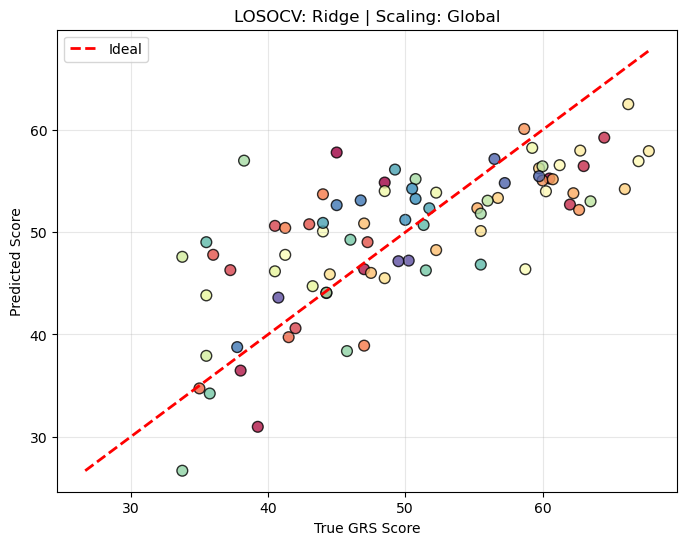

In [20]:
# with left pc1 and velocity corr => no added performance so go for simpler righ pc1 + vel_corr model
_, _, _ = evaluate_loso_model(df_full, top_features_right, extra_features=['pc1_left', 'velocity_corr'], model_class=Ridge, pca_components=[0], print_fold_metrics=False)

**Interpretation negative velocity correlation weight**

The Novice (High Correlation): Often moves both hands in a "mirroring" or "coupled" fashion because they lack the independent motor control to perform different tasks with each hand. When they move the right hand to pull a thread, the left hand "sympathetically" moves or trembles in the same direction.

The Expert (Lower Correlation): Experts exhibit bimanual functional dissociation. One hand is perfectly still (providing counter-traction) while the other hand moves at high speed. Or, one hand moves left while the other moves up. Their velocity profiles are uncoupled because their hands have specialized roles.


**Right Hand Only PC1**
Observations and reasoning for going with right_PC1 + vel_corr basline

all left and right hand features combines into pc1: 
problem:    
    - the explained variance of pc1 becomes less clear, pc1 drop in percentage of explained variance   
    - marginal improvement in R2 but lower MAE => does not justify it over righ hand only pc1
    - velocity correlation not as significantly helpfull explaining the residual variance   
    => stick with right hand features

Furthermore, a high correlation (r=0.80) was observed between dominant and non-dominant PC1 scores. Consequently, the 'Dominant Hand Paradigm' was adopted, utilizing only right-hand features for PC1. This approach preserves the statistical independence of the bimanual coordination signal and aligns with the orthopedic reality that the non-dominant hand often performs a stabilizing, secondary role...

## Statistical Significance?

In [174]:
all_shuffled_r2 = []
all_shuffled_vel_corr_r2 = []
all_shuffled_selection_stability = []
for seed in tqdm(range(500)):
    df_res = leakage_free_residual_analysis(df_full, top_features_right, candidate_features, top_n=1, perform_shuffle=True, seed=seed)
    top_r2 = df_res['Shuffled_R2_mean'].values[0]
    vel_corr_r2 = df_res[df_res['Feature']=='velocity_corr']['Shuffled_R2_mean'].values[0]
    sel_stab = df_res['Selection_Stability'].values[0]

    all_shuffled_vel_corr_r2.append(vel_corr_r2)
    all_shuffled_r2.append(top_r2)
    all_shuffled_selection_stability.append(sel_stab)

100%|██████████| 500/500 [23:35<00:00,  2.83s/it]


In [190]:
len([c for c in all_shuffled_selection_stability if c == 1]) / len(all_shuffled_selection_stability)

0.158

In [195]:
mask = np.array(all_shuffled_r2) > 0.09
subset = np.array(all_shuffled_selection_stability)[mask]
mask = subset == 1
mask.mean()

np.float64(0.3815789473684211)

Empirical p-value: 0.102
Z-score vs Null: 1.43


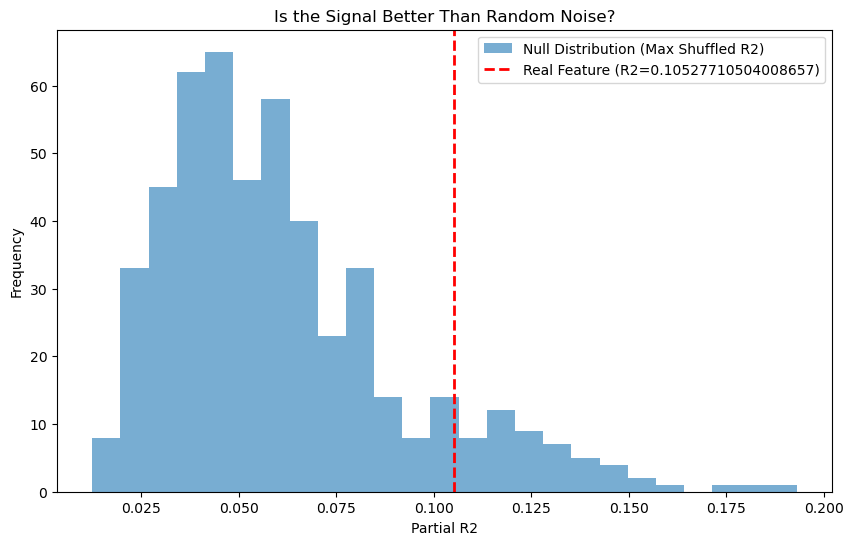

In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
        
# --- DATA INPUT ---
# Your top real feature R2
real_top_r2 = df_res_leakage_free['Partial_R2_mean'].values[0]

# Replace this with your actual list of 50 'Max' Shuffled R2 values 
# (The highest R2 observed in each of the 50 shuffle runs)

shuffled_max_r2s = all_shuffled_r2 # your 50 max values

def evaluate_significance(real_val, null_distribution):
    null_distribution = np.array(null_distribution)
    
    # Empirical p-value: what fraction of the null is >= our real signal?
    p_value = np.mean(null_distribution >= real_val)
    
    # Z-score: how many standard deviations is the real signal from the null mean?
    z_score = (real_val - np.mean(null_distribution)) / np.std(null_distribution)
    
    return p_value, z_score

p_val, z_score = evaluate_significance(real_top_r2, shuffled_max_r2s)

print(f"Empirical p-value: {p_val:.3f}")
print(f"Z-score vs Null: {z_score:.2f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.hist(shuffled_max_r2s, bins=25, alpha=0.6, label='Null Distribution (Max Shuffled R2)')
plt.axvline(real_top_r2, color='red', linestyle='--', linewidth=2, label=f'Real Feature (R2={real_top_r2})')
plt.title("Is the Signal Better Than Random Noise?")
plt.xlabel("Partial R2")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Take Different Cases into account

- With Dummy Case variable
- By standarizing the relevant features by case

In [15]:
# one hot encode Case_Number
df_case_onehot = pd.get_dummies(df_full['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in df_full.columns):
    df_full = pd.concat([df_full, df_case_onehot], axis=1)

In [23]:
candidate_features = list(set(candidate_features + list(df_case_onehot.columns)))
df_res_leakage_free = leakage_free_residual_analysis(df_full, top_features_right, candidate_features, base_features=['Case_1', 'Case_2', 'Case_3'], top_n=1, test_other_pcs=True)
df_res_leakage_free

,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
30,Velocity corr.,0.070185,0.013456,0.024779,-0.223418,0.892857
24,Rms accel. (L),0.048546,0.009891,0.018120,-0.180301,0.035714
6,Fraction tracked (L),0.031997,0.006614,0.018670,0.131101,0.000000
13,Mean vel. (R),0.030177,0.008811,0.011793,-0.093090,0.000000
10,Mean ang. change (L),0.029934,0.007653,0.010823,-0.128560,0.000000
17,Orientation entropy (R),0.029291,0.006677,0.014548,-0.149643,0.000000
26,Rotation over distance (L),0.025396,0.010781,0.014730,-0.133619,0.035714
14,Movement overlap ratio,0.021791,0.008735,0.005231,-0.122074,0.000000
31,Velocity ratio,0.020004,0.007323,0.004470,-0.116780,0.000000
9,LDLJ smoothness (L),0.017878,0.008467,0.005185,0.107233,0.035714


In [164]:
np.logspace(-2, 0.5, 20)

array([0.01      , 0.01353876, 0.01832981, 0.02481629, 0.03359818,
       0.04548778, 0.06158482, 0.08337822, 0.11288379, 0.15283067,
       0.20691381, 0.28013568, 0.37926902, 0.51348329, 0.6951928 ,
       0.94120497, 1.27427499, 1.72521055, 2.33572147, 3.16227766])

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 64.86it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7165 | MAE: 5.2231 | MAE STD: 3.9821 | R2: 0.5021 | Adj R2: 0.4698

Feature Weights:
  Feature  Average_Weight  Std_Weight
0    bias       49.967973    0.301544
1     PC1       -6.387595    0.153871
2  Case_1       -1.697648    0.106090
3  Case_2       -0.733803    0.172540
4  Case_3        2.431451    0.149774

--- Per-Fold Performance Summary ---


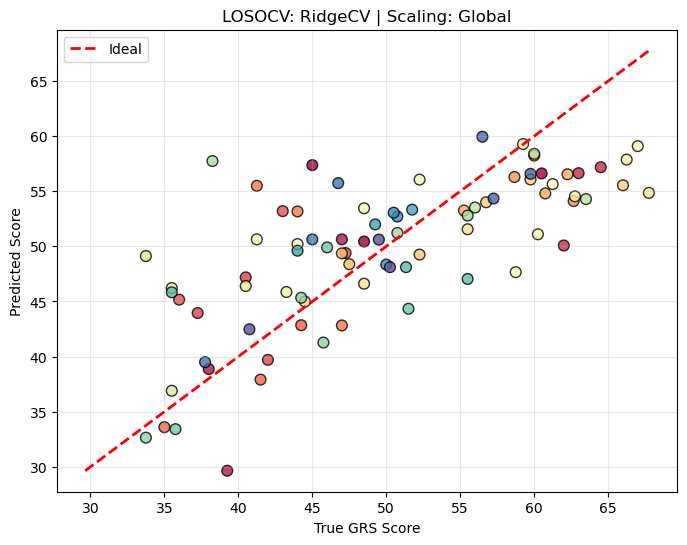

In [17]:
from sklearn.linear_model import RidgeCV
_, _, _ = evaluate_loso_model(df_full, top_features_right, extra_features=['Case_1', 'Case_2', 'Case_3'], model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 0.5, 20)}, pca_components=[0])

In [ ]:
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble, run_nested_loso

df_nested_results = run_nested_loso(
    df=df_full,
    primary_features=top_features_right,
    candidate_features=candidate_features,
    extra_features=['Case_1', 'Case_2','Case_3'],
    model_type='mlp',
    model_params={'hidden_dim': 16, 'n_hidden': 2, 'n_models': 5, 'dropout': 0.1, 'batch_size': 16},
    top_n=0,
    print_fold_metrics=True,
)

""" with case 1 & 3
MAE: 5.0126 +/- 4.0991
Train MAE: 4.6169
Spearman R: 0.7126
Overall R2: 0.5161"""

"""now also with frac tracked"""

Surgeon 1 | Train MAE: 4.5554 | Test MAE: 5.8622 | Selected Features: [] | Selected PR2s: []
Surgeon 2 | Train MAE: 4.6565 | Test MAE: 3.6425 | Selected Features: [] | Selected PR2s: []
Surgeon 3 | Train MAE: 4.5054 | Test MAE: 8.5216 | Selected Features: [] | Selected PR2s: []
Surgeon 4 | Train MAE: 4.7035 | Test MAE: 3.7103 | Selected Features: [] | Selected PR2s: []
Surgeon 5 | Train MAE: 4.6614 | Test MAE: 6.1363 | Selected Features: [] | Selected PR2s: []
Surgeon 6 | Train MAE: 4.7505 | Test MAE: 1.5209 | Selected Features: [] | Selected PR2s: []
Surgeon 7 | Train MAE: 4.4330 | Test MAE: 9.7558 | Selected Features: [] | Selected PR2s: []
Surgeon 9 | Train MAE: 4.7107 | Test MAE: 3.2791 | Selected Features: [] | Selected PR2s: []
Surgeon 10 | Train MAE: 4.7077 | Test MAE: 3.7077 | Selected Features: [] | Selected PR2s: []
Surgeon 11 | Train MAE: 4.7450 | Test MAE: 1.9078 | Selected Features: [] | Selected PR2s: []
Surgeon 12 | Train MAE: 4.6599 | Test MAE: 5.0022 | Selected Feature

'now also with frac tracked'

### Standarize by Case

While case-wise standardization is theoretically ideal for removing task-confounds, the limited sample size per task (N=27) likely introduces instability in the feature distributions. A Dummy Variable approach was adopted instead, as it allowed the model to account for baseline shifts in task difficulty (intercept) while maintaining the stability of the global kinematic distributions (slopes).


In [40]:
df_full[all_features].describe()

,total_path_Left,total_duration_Left,mean_velocity_Left,rms_accel_Left,ldlj_smoothness_Left,nmu_peaks_Left,efficiency_Left,mean_abs_angle_change_Left,stationary_time_ratio_Left,workspace_area_Left,...,pose_variability_Right,rotation_over_dist_Right,fraction_tracked_Right,velocity_corr,interhand_dist_mean,interhand_dist_std,interhand_dist_cv,interhand_dist_change_rms,movement_overlap_ratio,velocity_ratio
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,8.300000e+01,...,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,50105.843412,564.619277,112.023257,1363.874365,-24.486151,589.433735,91.173296,0.159244,0.445301,6.362876e+05,...,0.941762,0.006572,0.792257,0.468253,377.276115,105.664066,0.282008,17.157742,0.259714,0.684139
std,15995.980491,210.516022,21.442279,291.824357,0.800839,223.074536,15.413501,0.025744,0.103372,1.820303e+05,...,0.149338,0.001479,0.064036,0.098990,36.583743,16.999801,0.048775,3.775723,0.062980,0.151460
min,18500.202319,288.000000,62.318805,776.888552,-26.288729,247.000000,57.181750,0.104335,0.236850,3.786620e+05,...,0.639699,0.003783,0.541457,0.169612,290.269750,73.672155,0.198122,10.138496,0.137096,0.367484
25%,39114.848906,409.633333,98.917700,1193.509056,-24.924024,430.000000,80.223629,0.141299,0.355890,5.062505e+05,...,0.834902,0.005475,0.764893,0.410820,353.327646,95.819491,0.244772,14.591171,0.217357,0.568556
50%,47013.539733,503.500000,113.533504,1347.609835,-24.468651,548.000000,91.836998,0.160150,0.449622,5.981828e+05,...,0.953563,0.006580,0.803235,0.477706,373.822463,101.593443,0.277323,16.711706,0.244434,0.657946
75%,59348.086591,655.650000,125.592764,1481.900240,-23.903558,692.500000,102.476123,0.171349,0.528183,7.328569e+05,...,1.051915,0.007525,0.832042,0.540426,404.334022,115.626744,0.312211,19.218681,0.298480,0.756871
max,100456.811147,1282.466667,160.154510,2814.638061,-22.985461,1525.000000,131.848898,0.290207,0.641928,1.237336e+06,...,1.247336,0.011707,0.907158,0.645097,497.612911,159.126168,0.403992,26.166113,0.434208,1.118990


In [66]:
# first over the entire feature set and verify if it affect correlations with scores
to_standardize_by_case = all_features

df_full_standardized = df_full.copy()

# Ensure float dtype upfront
df_full_standardized[to_standardize_by_case] = (
    df_full_standardized[to_standardize_by_case].astype(float)
)

groups = df_full_standardized.groupby('Case_Number')

for _, df_group in tqdm(groups, desc="Standardizing by case"):
    idx = df_group.index
    means = df_group[to_standardize_by_case].mean()
    stds = df_group[to_standardize_by_case].std()

    valid = stds > 0
    df_full_standardized.loc[idx, valid.index[valid]] = (
        (df_group.loc[:, valid.index[valid]] - means[valid]) #/ stds[valid]
    )

df_corr_summary = leakage_free_correlation_analysis(df_full_standardized, all_features, n=6)
df_corr_summary

Analyzing Folds: 100%|██████████| 28/28 [00:00<00:00, 28.15it/s]


,Feature,Mean_Corr_with_Target,Std_Corr_with_Target,Min_Corr_with_Target,Max_Corr_with_Target,Selection_Stability
18,num_reversals_Right,-0.724891,0.010699,-0.752968,-0.713898,1.000000
16,nmu_peaks_Right,-0.708477,0.011350,-0.736873,-0.692393,1.000000
34,total_path_Right,-0.699979,0.012754,-0.729805,-0.685738,1.000000
31,total_duration_Left,-0.657410,0.012708,-0.687871,-0.636138,1.000000
32,total_duration_Right,-0.656811,0.012768,-0.687326,-0.635478,1.000000
30,total_angular_path_Right,-0.654479,0.011884,-0.680885,-0.640488,0.964286
15,nmu_peaks_Left,-0.620452,0.014584,-0.649570,-0.592727,0.000000
8,ldlj_smoothness_Left,0.619289,0.016607,0.589621,0.671734,0.035714
17,num_reversals_Left,-0.614041,0.015270,-0.647569,-0.577110,0.000000
9,ldlj_smoothness_Right,0.609079,0.012218,0.583653,0.632277,0.000000


In [47]:
top_features = df_corr_summary[(abs(df_corr_summary['Min_Corr_with_Target']) > 0.6) & (abs(df_corr_summary['Max_Corr_with_Target']) > 0.6)]['Feature'].tolist()

# top feature intercorrelation
inter_corrs = df_full_standardized[top_features].corr()

# if over 97.5% correlated, drop second feature
to_drop = set()
for i in range(len(top_features)):
    for j in range(i+1, len(top_features)):
        feat1 = top_features[i]
        feat2 = top_features[j]
        if abs(inter_corrs.loc[feat1, feat2]) > 0.98:
            to_drop.add(feat2)

to_drop

top_right = [feat for feat in top_features if 'Right' in feat]

top_features = [feat for feat in top_features if feat not in to_drop]

NameError: name 'df_corr_summary' is not defined

In [70]:
inter_corrs

,num_reversals_Right,nmu_peaks_Right,total_path_Right,total_duration_Left,total_duration_Right,total_angular_path_Right
num_reversals_Right,1.000000,0.973312,0.962329,0.919982,0.921285,0.872835
nmu_peaks_Right,0.973312,1.000000,0.948945,0.927476,0.928691,0.882385
total_path_Right,0.962329,0.948945,1.000000,0.899856,0.901261,0.867077
total_duration_Left,0.919982,0.927476,0.899856,1.000000,0.999754,0.814808
total_duration_Right,0.921285,0.928691,0.901261,0.999754,1.000000,0.816963
total_angular_path_Right,0.872835,0.882385,0.867077,0.814808,0.816963,1.000000


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 61.22it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.6972 | MAE: 5.3909 | MAE STD: 4.0231 | R2: 0.4778 | Adj R2: 0.4510

Feature Weights:
  Feature  Average_Weight  Std_Weight
0    bias       49.938586    0.302804
1     PC1       -3.016121    0.072273
2     PC3        1.066003    0.188361
3     PC4        0.468600    0.495816

--- Per-Fold Performance Summary ---


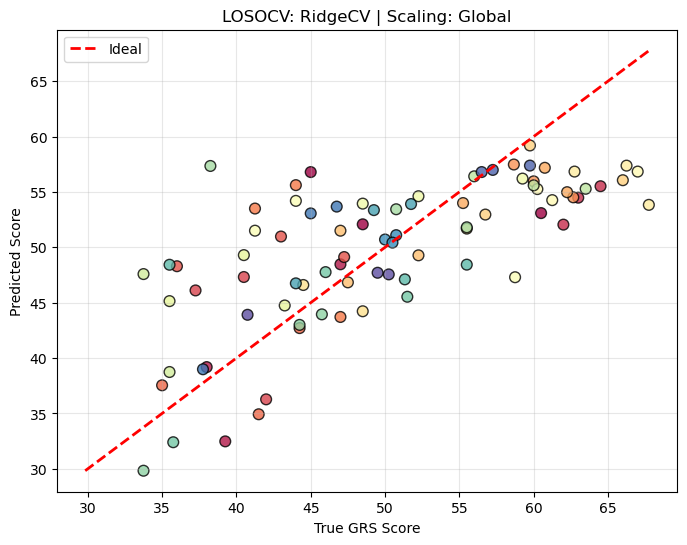

In [74]:
_, _, _ = evaluate_loso_model(df_full_standardized, top_features, model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 1, 20)}, pca_components=[0,2,3], scale_by_case=False)

Final Thesis Narrative

If I were writing this up, I would frame the Final Baseline as The "Two-Factor" Theory of Surgical Skill:

Factor 1: Efficiency (PC1)

Captures speed, path length, economy of motion.

Explains ~49% of the variance.

Factor 2: Bimanual Coordination (Velocity Correlation)

Captures how well the hands work together.

Explains an additional ~4% of unique variance (Partial R 
2
 ).

Task Context (Case Number)

"While task difficulty does shift the baseline scores, we exclude it from the primary model to ensure the metrics remain task-agnostic and robust."

Verdict

You are ready. Drop Step 8 (or keep it as a "secondary analysis" in the discussion), stick to the PC1 + Velocity Corr hybrid, and proceed. This is a very clean, defensible baseline.

In [18]:
# store the dataframe with only the top features
#df_full[['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'velocity_corr'] + top_features].to_csv("data/metrics/top_features_df.csv", index=False)

## **NN Model**



LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.2487 | Test MAE: 8.4920 | Test Corr: -0.6482
Surgeon 2 | Train MAE: 4.4993 | Test MAE: 2.4151 | Test Corr: 0.8542
Surgeon 3 | Train MAE: 4.4779 | Test MAE: 4.9538 | Test Corr: 0.9789
Surgeon 4 | Train MAE: 4.3822 | Test MAE: 6.8630 | Test Corr: -0.4047
Surgeon 5 | Train MAE: 4.4217 | Test MAE: 6.1969 | Test Corr: 0.5390
Surgeon 6 | Train MAE: 4.5582 | Test MAE: 1.2298 | Test Corr: 0.9585
Surgeon 7 | Train MAE: 4.3185 | Test MAE: 7.1236 | Test Corr: -0.8604
Surgeon 9 | Train MAE: 4.4185 | Test MAE: 5.5677 | Test Corr: -0.9150
Surgeon 10 | Train MAE: 4.4903 | Test MAE: 5.0523 | Test Corr: 0.8158
Surgeon 11 | Train MAE: 4.4661 | Test MAE: 3.0403 | Test Corr: -0.0418
Surgeon 12 | Train MAE: 4.4581 | Test MAE: 5.0288 | Test Corr: 0.1529
Surgeon 13 | Train MAE: 4.5282 | Test MAE: 3.3189 | Test Corr: 0.8925
Surgeon 14 | Train MAE: 4.5177 | Test MAE: 6.6225 | Test Corr: -0.2237
Surgeon 15 | Train MAE: 4.5394 | Test MAE: 5.7726 | Test Corr: 0.9463
Surgeon 16 | Train MAE

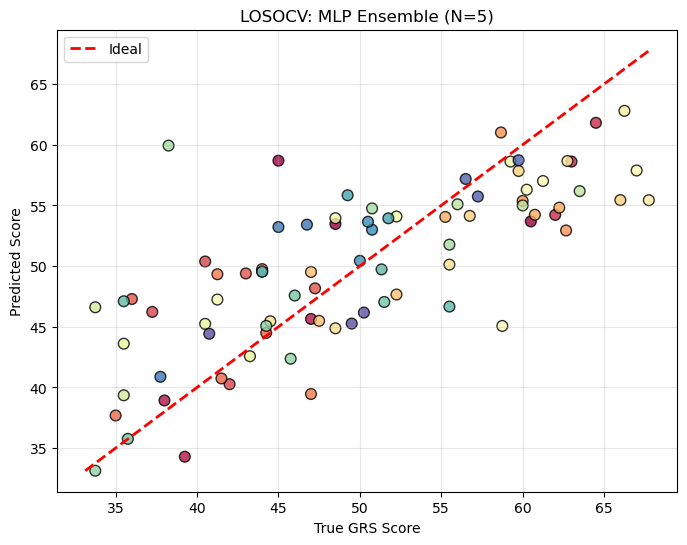

LOSOCV Ensemble Folds:   0%|          | 0/28 [04:26<?, ?it/s]


In [ ]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble

_, _, _ = evaluate_loso_mlp_ensemble(
    model_class=PyTorchMLPEnsemble,
    df=df_full,
    primary_features=top_features,
    extra_features=['velocity_corr'],
    model_params={'hidden_dim': 16, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    pca_components=[0],
    print_fold_metrics=True
)
    


try MLPs with PC1 + velocity_corr + other_features(s)

LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.2798 | Test MAE: 8.3270 | Test Corr: -0.6057
Surgeon 2 | Train MAE: 4.6497 | Test MAE: 2.3179 | Test Corr: 0.8360
Surgeon 3 | Train MAE: 4.5529 | Test MAE: 5.7396 | Test Corr: 0.9792
Surgeon 4 | Train MAE: 4.4621 | Test MAE: 6.4052 | Test Corr: -0.4174
Surgeon 5 | Train MAE: 4.5161 | Test MAE: 5.6447 | Test Corr: 0.6060
Surgeon 6 | Train MAE: 4.6349 | Test MAE: 1.4543 | Test Corr: 0.9458
Surgeon 7 | Train MAE: 4.4631 | Test MAE: 6.5567 | Test Corr: -0.8792
Surgeon 9 | Train MAE: 4.3899 | Test MAE: 5.5379 | Test Corr: -0.9342
Surgeon 10 | Train MAE: 4.4804 | Test MAE: 5.1950 | Test Corr: 0.7965
Surgeon 11 | Train MAE: 4.4872 | Test MAE: 3.1615 | Test Corr: -0.0852
Surgeon 12 | Train MAE: 4.4899 | Test MAE: 5.1484 | Test Corr: 0.1647
Surgeon 13 | Train MAE: 4.4480 | Test MAE: 3.8200 | Test Corr: 0.8802
Surgeon 14 | Train MAE: 4.5166 | Test MAE: 8.2004 | Test Corr: -0.3964
Surgeon 15 | Train MAE: 4.5881 | Test MAE: 5.8777 | Test Corr: 0.9135
Surgeon 16 | Train MAE

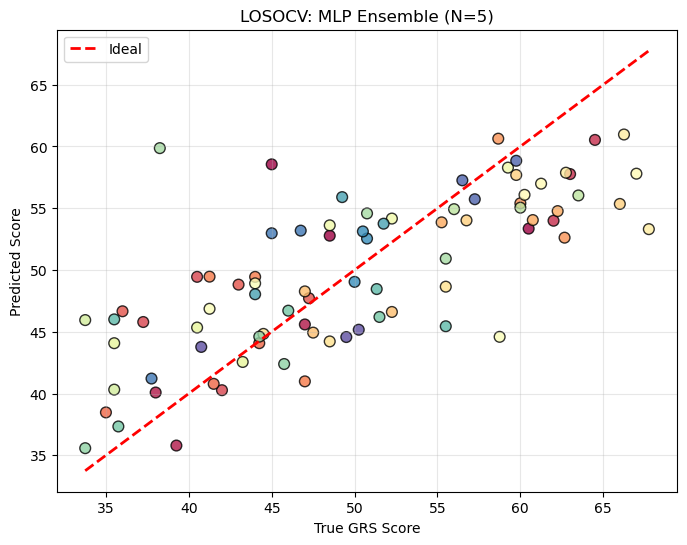

LOSOCV Ensemble Folds:   0%|          | 0/28 [05:48<?, ?it/s]


"\nextra_features=['velocity_corr', 'Case_1', 'Case_2', 'Case_3']\n\n------- dropout = 0.2 -------\nhidden_dim = 16\n=== LOSOCV Ensemble MLP Results (Global Scaling) ===\nSpearman R: 0.7491 | MAE: 4.7653 | MAE STD: 3.9071 | R2: 0.5617\n\nhidden_dim = 32\n=== LOSOCV Ensemble MLP Results (Global Scaling) ===\nSpearman R: 0.7534 | MAE: 4.6758 | MAE STD: 3.9171 | R2: 0.5706\n\nhidden_dim = 16, n_hidden=2\n=== LOSOCV Ensemble MLP Results (Global Scaling) ===\nSpearman R: 0.7416 | MAE: 4.8548 | MAE STD: 3.7990 | R2: 0.5614\n\n------- dropout = 0.15 -------\nhidden_dim = 16, layers=2\n=== LOSOCV Ensemble MLP Results (Global Scaling) ===\nSpearman R: 0.7495 | MAE: 4.7313 | MAE STD: 3.8520 | R2: 0.5704\n\nhidden_dim = 24, n_hidden=2\n=== LOSOCV Ensemble MLP Results (Global Scaling) ===\nSpearman R: 0.7546 | MAE: 4.6321 | MAE STD: 3.8108 | R2: 0.5847\n\nhidden_dim = 32, n_hidden=2\n=== LOSOCV Ensemble MLP Results (Global Scaling) ===\nSpearman R: 0.7490 | MAE: 4.6869 | MAE STD: 3.8471 | R2: 0.57

In [95]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble

f = 'interhand_dist_change_rms'
_, _, _ = evaluate_loso_mlp_ensemble(
    model_class=PyTorchMLPEnsemble,
    df=df_full,
    primary_features=top_features,
    extra_features=['velocity_corr'],
    model_params={'hidden_dim': 16, 'n_hidden': 2, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    pca_components=[0],
    print_fold_metrics=True
)
"""
extra_features=['velocity_corr', 'Case_1', 'Case_2', 'Case_3']

------- dropout = 0.2 -------
hidden_dim = 16
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7491 | MAE: 4.7653 | MAE STD: 3.9071 | R2: 0.5617

hidden_dim = 32
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7534 | MAE: 4.6758 | MAE STD: 3.9171 | R2: 0.5706

hidden_dim = 16, n_hidden=2
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7416 | MAE: 4.8548 | MAE STD: 3.7990 | R2: 0.5614

------- dropout = 0.15 -------
hidden_dim = 16, layers=2
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7495 | MAE: 4.7313 | MAE STD: 3.8520 | R2: 0.5704

hidden_dim = 24, n_hidden=2
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7546 | MAE: 4.6321 | MAE STD: 3.8108 | R2: 0.5847

hidden_dim = 32, n_hidden=2
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7490 | MAE: 4.6869 | MAE STD: 3.8471 | R2: 0.5756

extra_features=['velocity_corr', 'Case_1', 'Case_2', 'Case_3', 'interhand_dist_change_rms']
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7481 | MAE: 4.8682 | MAE STD: 3.7360 | R2: 0.5654
"""

Evaluating with extra feature: interhand_dist_change_rms


LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.1293 | Test MAE: 8.5376 | Test Corr: -0.6334
Surgeon 2 | Train MAE: 4.4093 | Test MAE: 2.3754 | Test Corr: 0.8460
Surgeon 3 | Train MAE: 4.3946 | Test MAE: 5.3697 | Test Corr: 0.9814
Surgeon 4 | Train MAE: 4.2828 | Test MAE: 6.5424 | Test Corr: -0.3929
Surgeon 5 | Train MAE: 4.3278 | Test MAE: 5.5348 | Test Corr: 0.6086
Surgeon 6 | Train MAE: 4.4847 | Test MAE: 1.3083 | Test Corr: 0.9799
Surgeon 7 | Train MAE: 4.2905 | Test MAE: 6.5988 | Test Corr: -0.8624
Surgeon 9 | Train MAE: 4.3560 | Test MAE: 5.0875 | Test Corr: -0.9399
Surgeon 10 | Train MAE: 4.3690 | Test MAE: 5.7167 | Test Corr: 0.9636
Surgeon 11 | Train MAE: 4.4109 | Test MAE: 3.1701 | Test Corr: -0.0331
Surgeon 12 | Train MAE: 4.3868 | Test MAE: 4.6198 | Test Corr: 0.2384
Surgeon 13 | Train MAE: 4.4062 | Test MAE: 3.3220 | Test Corr: 0.8952
Surgeon 14 | Train MAE: 4.4024 | Test MAE: 6.7761 | Test Corr: -0.2179
Surgeon 15 | Train MAE: 4.4152 | Test MAE: 5.3450 | Test Corr: 0.9102
Surgeon 16 | Train MAE

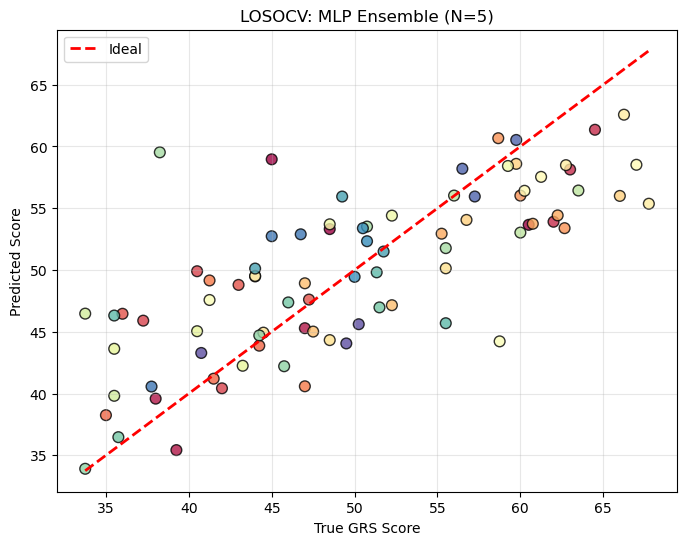

LOSOCV Ensemble Folds:   0%|          | 0/28 [03:09<?, ?it/s]


Evaluating with extra feature: mean_velocity_Left


LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.1929 | Test MAE: 8.3071 | Test Corr: -0.5515
Surgeon 2 | Train MAE: 4.4063 | Test MAE: 2.3502 | Test Corr: 0.8616
Surgeon 3 | Train MAE: 4.3635 | Test MAE: 5.6199 | Test Corr: 0.9843
Surgeon 4 | Train MAE: 4.3377 | Test MAE: 6.3238 | Test Corr: -0.3559
Surgeon 5 | Train MAE: 4.3465 | Test MAE: 5.7708 | Test Corr: 0.7119
Surgeon 6 | Train MAE: 4.5133 | Test MAE: 1.2918 | Test Corr: 0.9868
Surgeon 7 | Train MAE: 4.3030 | Test MAE: 6.6114 | Test Corr: -0.8925
Surgeon 9 | Train MAE: 4.2587 | Test MAE: 6.2666 | Test Corr: -0.9228
Surgeon 10 | Train MAE: 4.3306 | Test MAE: 5.4391 | Test Corr: 0.7484
Surgeon 11 | Train MAE: 4.4082 | Test MAE: 3.0458 | Test Corr: 0.0187
Surgeon 12 | Train MAE: 4.4000 | Test MAE: 5.1525 | Test Corr: 0.1057
Surgeon 13 | Train MAE: 4.3675 | Test MAE: 3.3312 | Test Corr: 0.9197
Surgeon 14 | Train MAE: 4.3671 | Test MAE: 8.9511 | Test Corr: -0.2784
Surgeon 15 | Train MAE: 4.3873 | Test MAE: 5.6550 | Test Corr: 0.8961
Surgeon 16 | Train MAE:

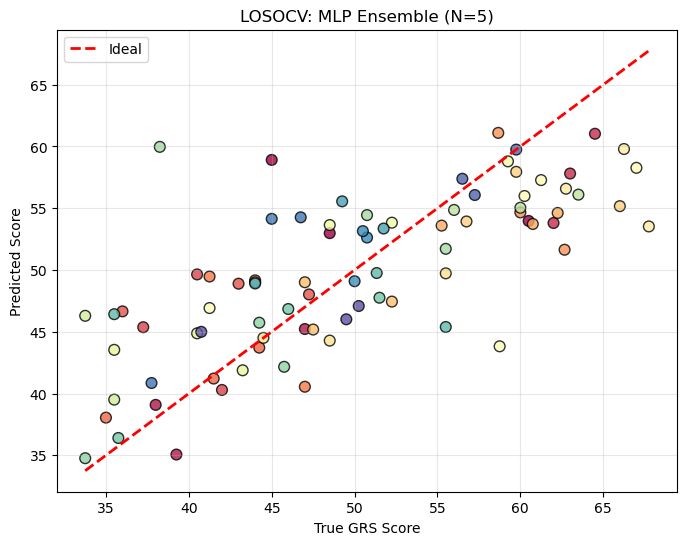

LOSOCV Ensemble Folds:   0%|          | 0/28 [05:07<?, ?it/s]


Evaluating with extra feature: workspace_area_Right


LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.1200 | Test MAE: 9.4856 | Test Corr: -0.8649
Surgeon 2 | Train MAE: 4.4019 | Test MAE: 2.2555 | Test Corr: 0.8550
Surgeon 3 | Train MAE: 4.4103 | Test MAE: 5.4604 | Test Corr: 0.9851
Surgeon 4 | Train MAE: 4.3333 | Test MAE: 6.9609 | Test Corr: -0.4262
Surgeon 5 | Train MAE: 4.3624 | Test MAE: 5.8950 | Test Corr: 0.4020
Surgeon 6 | Train MAE: 4.4768 | Test MAE: 1.3369 | Test Corr: 0.9998
Surgeon 7 | Train MAE: 4.2616 | Test MAE: 7.0858 | Test Corr: -0.8858
Surgeon 9 | Train MAE: 4.3530 | Test MAE: 5.4160 | Test Corr: -0.9231
Surgeon 10 | Train MAE: 4.3807 | Test MAE: 5.2010 | Test Corr: 0.9791
Surgeon 11 | Train MAE: 4.4016 | Test MAE: 3.1853 | Test Corr: -0.0249
Surgeon 12 | Train MAE: 4.3942 | Test MAE: 4.9709 | Test Corr: 0.0710
Surgeon 13 | Train MAE: 4.4177 | Test MAE: 3.3305 | Test Corr: 0.9319
Surgeon 14 | Train MAE: 4.3885 | Test MAE: 6.9455 | Test Corr: -0.2619
Surgeon 15 | Train MAE: 4.4207 | Test MAE: 5.7253 | Test Corr: 0.9387
Surgeon 16 | Train MAE

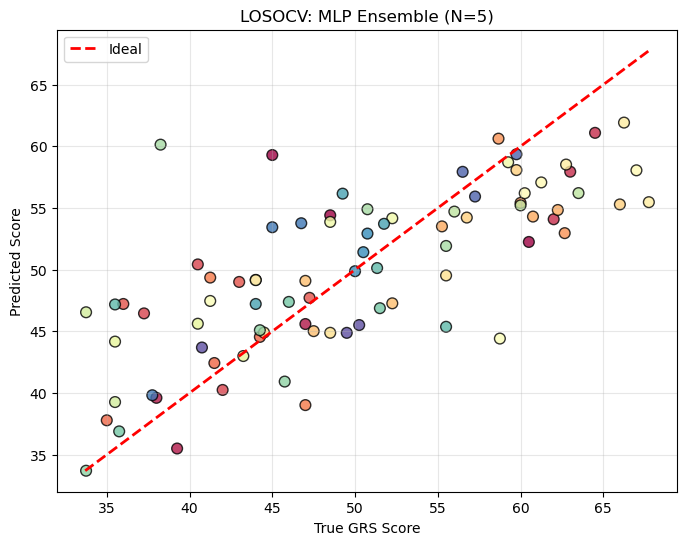

LOSOCV Ensemble Folds:   0%|          | 0/28 [05:43<?, ?it/s]


Evaluating with extra feature: pose_variability_Right


LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.2656 | Test MAE: 8.1652 | Test Corr: -0.5669
Surgeon 2 | Train MAE: 4.3943 | Test MAE: 2.7414 | Test Corr: 0.8537
Surgeon 3 | Train MAE: 4.3852 | Test MAE: 4.7732 | Test Corr: 0.9498
Surgeon 4 | Train MAE: 4.3124 | Test MAE: 6.4754 | Test Corr: -0.1858
Surgeon 5 | Train MAE: 4.3570 | Test MAE: 7.3681 | Test Corr: 0.6693
Surgeon 6 | Train MAE: 4.5211 | Test MAE: 1.7610 | Test Corr: 0.9186
Surgeon 7 | Train MAE: 4.2856 | Test MAE: 6.3429 | Test Corr: -0.8745
Surgeon 9 | Train MAE: 4.3528 | Test MAE: 5.0855 | Test Corr: -0.9285
Surgeon 10 | Train MAE: 4.3565 | Test MAE: 6.0998 | Test Corr: -0.4073
Surgeon 11 | Train MAE: 4.4576 | Test MAE: 2.1437 | Test Corr: -0.7725
Surgeon 12 | Train MAE: 4.4305 | Test MAE: 5.3215 | Test Corr: 0.2153
Surgeon 13 | Train MAE: 4.4417 | Test MAE: 3.1095 | Test Corr: 0.8631
Surgeon 14 | Train MAE: 4.4274 | Test MAE: 6.7752 | Test Corr: 0.0880
Surgeon 15 | Train MAE: 4.4189 | Test MAE: 6.6340 | Test Corr: 0.2708
Surgeon 16 | Train MAE

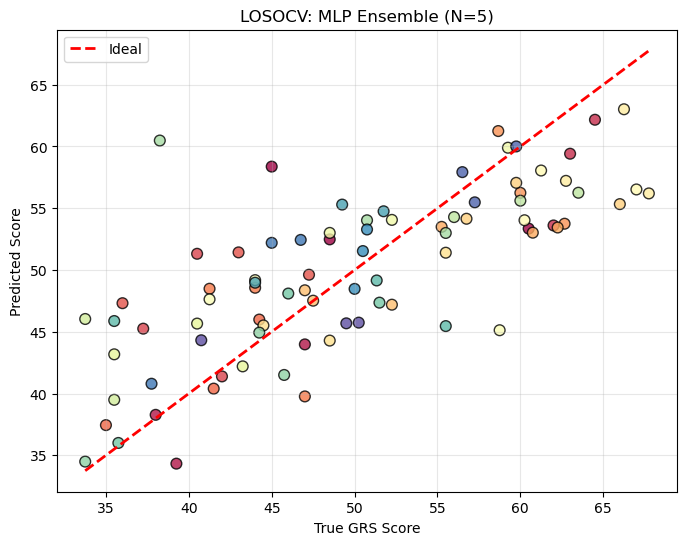

LOSOCV Ensemble Folds:   0%|          | 0/28 [05:03<?, ?it/s]


Evaluating with extra feature: fraction_tracked_Right


LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.1285 | Test MAE: 8.4787 | Test Corr: -0.5644
Surgeon 2 | Train MAE: 4.3972 | Test MAE: 1.5993 | Test Corr: 0.9641
Surgeon 3 | Train MAE: 4.3136 | Test MAE: 6.0870 | Test Corr: 0.9973
Surgeon 4 | Train MAE: 4.2409 | Test MAE: 6.0621 | Test Corr: -0.2111
Surgeon 5 | Train MAE: 4.2954 | Test MAE: 5.5308 | Test Corr: 0.6023
Surgeon 6 | Train MAE: 4.4322 | Test MAE: 1.0959 | Test Corr: 0.9698
Surgeon 7 | Train MAE: 4.1768 | Test MAE: 7.1683 | Test Corr: -0.8585
Surgeon 9 | Train MAE: 4.2772 | Test MAE: 5.6275 | Test Corr: -0.8987
Surgeon 10 | Train MAE: 4.3015 | Test MAE: 5.5558 | Test Corr: 0.9202
Surgeon 11 | Train MAE: 4.3699 | Test MAE: 2.8533 | Test Corr: -0.4404
Surgeon 12 | Train MAE: 4.3303 | Test MAE: 4.3758 | Test Corr: 0.3009
Surgeon 13 | Train MAE: 4.3570 | Test MAE: 3.5626 | Test Corr: 0.9998
Surgeon 14 | Train MAE: 4.3190 | Test MAE: 8.0254 | Test Corr: -0.8876
Surgeon 15 | Train MAE: 4.2881 | Test MAE: 4.0244 | Test Corr: 0.9972
Surgeon 16 | Train MAE

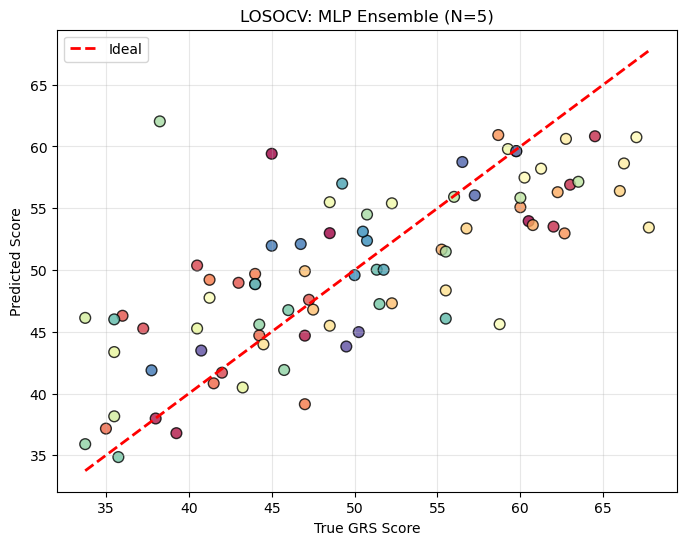

LOSOCV Ensemble Folds:   0%|          | 0/28 [04:57<?, ?it/s]


: 

: 

In [ ]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble
features_to_try = ['interhand_dist_change_rms', 'mean_velocity_Left', 'workspace_area_Right', 'pose_variability_Right', 'fraction_tracked_Right']

for f in features_to_try:
    print(f"Evaluating with extra feature: {f}")
    _, _, _ = evaluate_loso_mlp_ensemble(
        model_class=PyTorchMLPEnsemble,
        df=df_full,
        primary_features=top_features,
        extra_features=['velocity_corr', f],
        model_params={'hidden_dim': 16, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
        pca_components=[0],
        print_fold_metrics=True
    )

# Totally data driven nested global feature selection

- take globals with corr > 0.6 from in training fold
- remove those with intercorr > 0.95 (the one with the lower corr with scores)
- PCA of these globals
- selectet out of remaining features using partial r2
- evalue perf

In [158]:
from src_final.models.baseline_loso  import run_automated_nested_loso

results_df, global_stability, local_stability = run_automated_nested_loso(
    df=df_full,
    feature_pool=right_features,
    model_type='ridge',
    model_params={'hidden_dim': 16, 'n_hidden': 2, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    top_n=1,
    print_fold_metrics=True,
    global_corr_threshold=0.5,
    global_redundancy_threshold=0.99,
    corr_threshold=0.8,
    pr2_threshold=0.00,
    #top_n_globals=
)

Surgeon 1 | Globals: 5,  PC1 Explained Var: 0.8715 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1154)]
Surgeon 2 | Globals: 5,  PC1 Explained Var: 0.8681 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1076)]
Surgeon 3 | Globals: 5,  PC1 Explained Var: 0.8688 | Locals: ['velocity_corr'] with PR2s [np.float64(0.0829)]
Surgeon 4 | Globals: 5,  PC1 Explained Var: 0.8716 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1183)]
Surgeon 5 | Globals: 5,  PC1 Explained Var: 0.8721 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1154)]
Surgeon 6 | Globals: 5,  PC1 Explained Var: 0.8613 | Locals: ['velocity_corr'] with PR2s [np.float64(0.0967)]
Surgeon 7 | Globals: 5,  PC1 Explained Var: 0.8700 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1063)]
Surgeon 9 | Globals: 5,  PC1 Explained Var: 0.8675 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1242)]
Surgeon 10 | Globals: 5,  PC1 Explained Var: 0.8706 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1156)]
Surgeon 1

In [87]:
df_full[['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'velocity_corr'] + [i for i in global_stability.index] + ['total_duration_Right']].to_csv("data/metrics/global_pc1_features.csv", index=False)

In [86]:
[i for i in global_stability.index]

['angular_dir_switches_Right',
 'nmu_peaks_Right',
 'total_duration_Left',
 'total_path_Right',
 'angular_dir_switches_Left',
 'nmu_peaks_Left',
 'ldlj_smoothness_Left',
 'total_path_Left',
 'total_angular_path_Right',
 'ldlj_smoothness_Right',
 'total_angular_path_Left']